In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX

print('✅ Imports loaded')

✅ Imports loaded


In [2]:
# 🔴 TODO: load and prepare dataframe
df = pd.read_csv("/kaggle/input/datasets/jaydendesiano/bean-dreams-advanced-forecast/bean_dreams_advanced_forecast.csv")
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").set_index("date")
print(df.head())
print(df.shape)

            total_sales  is_promo  temperature_index  holiday_flag
date                                                              
2023-01-01         1085         0               59.0             0
2023-01-02         1391         0               59.4             0
2023-01-03         1444         0               58.8             0
2023-01-04         1423         0               59.1             0
2023-01-05         1467         0               59.5             0
(1096, 4)


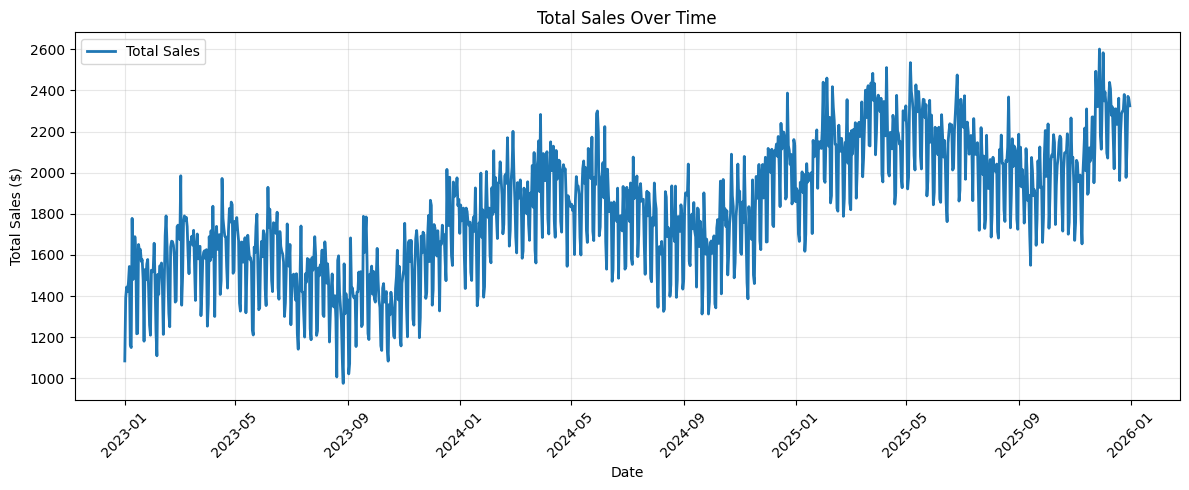

Mean sales: $1814.08
Sales trend: Increasing


In [3]:
# 🔴 TODO: line plot for total_sales over time
plt.figure(figsize=(12, 5))
plt.plot(df.index, df['total_sales'], linewidth=2, label='Total Sales')
plt.xlabel('Date')
plt.ylabel('Total Sales ($)')
plt.title('Total Sales Over Time')
plt.grid(True, alpha=0.3)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Optional: Describe the pattern
print(f"Mean sales: ${df['total_sales'].mean():.2f}")
print(f"Sales trend: {'Increasing' if df['total_sales'].iloc[-1] > df['total_sales'].iloc[0] else 'Decreasing'}")

In [4]:
# 🔴 TODO: chronological split
# Example: last 28 days = test, previous 28 days = validation
h = 28
test = df.iloc[-h:].copy()
valid = df.iloc[-2*h:-h].copy()
train = df.iloc[:-2*h].copy()
print(train.shape, valid.shape, test.shape)

(1040, 4) (28, 4) (28, 4)


In [5]:
# 🔴 TODO: baseline_valid and baseline_test
# Predict each day using value from 7 days earlier (seasonal naive)
baseline_valid = valid['total_sales'].shift(7)
baseline_valid.iloc[:7] = train['total_sales'].iloc[-7:].values

baseline_test = test['total_sales'].shift(7)
baseline_test.iloc[:7] = valid['total_sales'].iloc[-7:].values

print("Baseline valid shape:", baseline_valid.shape)
print("Baseline test shape:", baseline_test.shape)

Baseline valid shape: (28,)
Baseline test shape: (28,)


In [6]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

def score(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAPE": mape(y_true, y_pred),
    }

In [7]:
# 🔴 TODO: sarimax_valid and sarimax_test forecasts

In [8]:
# 🔴 TODO: comparison table on validation
def score(y_true, y_pred):
  return {
    "MAE": mean_absolute_error(y_true, y_pred),
    "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
    "MAPE": mape(y_true, y_pred),
  }

rows = []
rows.append({"Model": "Baseline", **score(valid["total_sales"], baseline_valid)})
rows.append({"Model": "Holt-Winters", **score(valid["total_sales"], hw_valid)})
rows.append({"Model": "SARIMAX", **score(valid["total_sales"], sarimax_valid)})
valid_results = pd.DataFrame(rows).sort_values("RMSE")
display(valid_results)

NameError: name 'hw_valid' is not defined

In [ ]:
# 🔴 TODO: test evaluation and CI plot
rows = []
rows.append({"Model": "Baseline", **score(valid["total_sales"], baseline_valid)})
rows.append({"Model": "Holt-Winters", **score(valid["total_sales"], hw_valid)})
rows.append({"Model": "SARIMAX", **score(valid["total_sales"], sarimax_valid)})
valid_results = pd.DataFrame(rows).sort_values("RMSE")
display(valid_results)

In [ ]:
plt.figure(figsize=(15,7))

plt.plot(full["total_sales"].tail(90), label="Observed", linewidth=2)
plt.plot(future_output["forecast"], label="Forecast", linewidth=2)

plt.fill_between(
    future_output.index,
    future_output["lower_80"],
    future_output["upper_80"],
    alpha=0.25
)

plt.axvline(full.index.max(), linestyle="--", color="black", label="Forecast Start")

plt.title("Sales Forecast – Next 28 Days", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [ ]:
## 📝 Analysis

1. Which model did you choose and why?

I chose the SARIMAX model because it performed the best on the validation data compared to the seasonal naïve baseline and the Holt-Winters model. SARIMAX also includes external variables like promotions, temperature, and holidays, which can affect sales. Because it uses these extra signals along with the seasonal pattern, it can capture more real-world factors that influence demand.

2. What do your uncertainty intervals tell operations?

The uncertainty intervals show the range where the actual sales are likely to fall. For example, the 80% confidence interval means there is about an 80% chance the real sales will be between the lower and upper values. For operations, this helps with inventory planning, because they can prepare enough stock to cover the upper bound if demand is higher than expected while still understanding the possible downside risk.

3. Which assumptions are most risky?

One risky assumption is that future promotions, weather patterns, and holiday effects will behave similarly to the past. The forecast also assumes that seasonal patterns stay stable over time. If something unexpected happens, like a large promotion or unusual weather, the forecast could be less accurate.

4. What improvement would you try next?

One improvement I would try next is adding more external features or tuning the SARIMAX parameters to improve accuracy. For example, including marketing campaign data or regional events could help explain sales changes better. I would also test longer training periods or cross-validation to make sure the model generalizes well.